# Flight Operation Logic

This notebook builds AI logic for the Flight Operation module: live flight board generation, arrival/departure sync, gate assignment, parking bay allocation, runway scheduling, GPU allocation, turnaround scoring, conflict detection, and operational recommendations.

## 1. Setup

In [1]:
import random
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)

now = datetime(2026, 4, 27, 9, 0)

## 2. Airport Configuration

In [2]:
AIRLINES = ['IndiGo', 'Air India', 'SpiceJet', 'Vistara', 'Akasa', 'AirAsia']
STATUS_VALUES = ['On Time', 'Delayed', 'Boarding', 'Departed', 'Arrived', 'Turnaround']
RUNWAYS = ['RWY 09L', 'RWY 09R', 'RWY 27L', 'RWY 27R']
PARKING_BAYS = ['Bay A1', 'Bay A2', 'Bay A3', 'Bay B1', 'Bay B2', 'Bay C1', 'Bay C2', 'Bay D1']
GATES = [f'G{str(i).zfill(2)}' for i in range(1, 25)]
BAGGAGE_BELTS = [f'B{str(i).zfill(2)}' for i in range(1, 11)]
GPU_UNITS = [f'GPU-{str(i).zfill(2)}' for i in range(1, 21)]

AIRCRAFT_PROFILES = {
    'ATR72': {'turnaround_target': 32, 'passengers': (45, 72), 'gate_type': 'regional', 'gpu_need': 0.7},
    'A320': {'turnaround_target': 45, 'passengers': (130, 180), 'gate_type': 'narrow_body', 'gpu_need': 1.0},
    'B737': {'turnaround_target': 48, 'passengers': (140, 190), 'gate_type': 'narrow_body', 'gpu_need': 1.0},
    'A321': {'turnaround_target': 55, 'passengers': (180, 235), 'gate_type': 'narrow_body', 'gpu_need': 1.1},
    'B777': {'turnaround_target': 85, 'passengers': (280, 390), 'gate_type': 'wide_body', 'gpu_need': 1.6},
    'A350': {'turnaround_target': 90, 'passengers': (300, 420), 'gate_type': 'wide_body', 'gpu_need': 1.7},
}

gate_profile = pd.DataFrame({
    'gate': GATES,
    'terminal': [random.choice(['T1', 'T2', 'T3']) for _ in GATES],
    'gate_type': ['wide_body' if i in [4, 8, 12, 16, 20, 24] else 'narrow_body' if i % 5 else 'regional' for i in range(1, 25)],
    'status': ['closed' if i in [7, 19] else 'available' for i in range(1, 25)],
})
gate_profile.head()

,gate,terminal,gate_type,status
0,G01,T3,narrow_body,available
1,G02,T1,narrow_body,available
2,G03,T1,narrow_body,available
3,G04,T3,wide_body,available
4,G05,T2,regional,available


## 3. Generate Live Flight Board

In [3]:
def format_time(ts):
    return ts.strftime('%H:%M')


def generate_live_flights(n=36, start_time=now):
    rows = []
    stations = ['DEL', 'BOM', 'BLR', 'HYD', 'MAA', 'CCU', 'GOI', 'DXB', 'SIN']
    priority_rank_map = {'Normal': 0, 'Cargo': 1, 'VIP': 2, 'Connection Critical': 3, 'Emergency': 4}

    for i in range(n):
        aircraft = random.choice(list(AIRCRAFT_PROFILES.keys()))
        profile = AIRCRAFT_PROFILES[aircraft]
        is_arrival = random.random() > 0.45
        scheduled_arrival = start_time + timedelta(minutes=random.randint(-120, 210))
        arrival_delay = int(np.random.normal(loc=7, scale=16))
        arrival_delay = max(-10, arrival_delay)
        actual_arrival = scheduled_arrival + timedelta(minutes=arrival_delay)
        turnaround_buffer = random.randint(8, 35)
        scheduled_departure = scheduled_arrival + timedelta(minutes=profile['turnaround_target'] + turnaround_buffer)
        departure_delay = max(arrival_delay + random.randint(-5, 18), -5)
        actual_departure = scheduled_departure + timedelta(minutes=departure_delay)
        airline = random.choice(AIRLINES)
        prefix = {'IndiGo': '6E', 'Air India': 'AI', 'SpiceJet': 'SG', 'Vistara': 'UK', 'Akasa': 'QP', 'AirAsia': 'I5'}[airline]
        origin, destination = random.sample(stations, 2)
        priority = random.choices(['Normal', 'VIP', 'Emergency', 'Cargo', 'Connection Critical'], weights=[70, 6, 3, 8, 13])[0]

        rows.append({
            'id': f'FL-{1000 + i}',
            'flight_id': f'{prefix}{random.randint(100, 999)}',
            'airline': airline,
            'aircraft_type': aircraft,
            'origin': origin,
            'destination': destination,
            'scheduled_arrival': scheduled_arrival,
            'actual_arrival': actual_arrival,
            'scheduled_departure': scheduled_departure,
            'actual_departure': actual_departure,
            'arrival_delay_min': arrival_delay,
            'departure_delay_min': departure_delay,
            'status': random.choices(STATUS_VALUES, weights=[30, 18, 13, 12, 15, 12])[0],
            'is_arrival': is_arrival,
            'passengers': random.randint(*profile['passengers']),
            'cargo_kg': random.randint(600, 8500),
            'priority': priority,
            'priority_rank': priority_rank_map[priority],
            'required_gate_type': profile['gate_type'],
            'turnaround_target_min': profile['turnaround_target'],
            'gpu_need': profile['gpu_need'],
        })

    flights = pd.DataFrame(rows)
    flights['turnaround_actual_min'] = (flights['actual_departure'] - flights['actual_arrival']).dt.total_seconds() / 60
    flights['scheduled_arrival_time'] = flights['scheduled_arrival'].map(format_time)
    flights['actual_arrival_time'] = flights['actual_arrival'].map(format_time)
    flights['scheduled_departure_time'] = flights['scheduled_departure'].map(format_time)
    flights['actual_departure_time'] = flights['actual_departure'].map(format_time)
    flights['minutes_to_arrival'] = ((flights['scheduled_arrival'] - start_time).dt.total_seconds() / 60).round(1)
    flights['minutes_to_departure'] = ((flights['scheduled_departure'] - start_time).dt.total_seconds() / 60).round(1)
    flights['departure_buffer_min'] = (flights['minutes_to_departure'] - flights['turnaround_target_min']).round(1)
    flights['ops_priority_score'] = (
        flights['priority_rank'] * 12 +
        np.maximum(0, 45 - flights['minutes_to_departure']) * 0.7 +
        np.maximum(flights['arrival_delay_min'], 0) * 0.45
    ).round(1)
    return flights.sort_values(['ops_priority_score', 'scheduled_arrival'], ascending=[False, True]).reset_index(drop=True)


flights_df = generate_live_flights()
flights_df.head(10)


,id,flight_id,airline,aircraft_type,origin,destination,scheduled_arrival,actual_arrival,scheduled_departure,actual_departure,arrival_delay_min,departure_delay_min,status,is_arrival,passengers,cargo_kg,priority,priority_rank,required_gate_type,turnaround_target_min,gpu_need,turnaround_actual_min,scheduled_arrival_time,actual_arrival_time,scheduled_departure_time,actual_departure_time,minutes_to_arrival,minutes_to_departure,departure_buffer_min,ops_priority_score
0,FL-1020,UK848,Vistara,ATR72,MAA,GOI,2026-04-27 07:01:00,2026-04-27 07:31:00,2026-04-27 07:53:00,2026-04-27 08:26:00,30,33,Turnaround,False,62,6022,Normal,0,regional,32,0.7,55.0,07:01,07:31,07:53,08:26,-119.0,-67.0,-99.0,91.9
1,FL-1003,UK314,Vistara,ATR72,CCU,BLR,2026-04-27 07:51:00,2026-04-27 08:22:00,2026-04-27 08:43:00,2026-04-27 09:17:00,31,34,Departed,True,67,8273,Normal,0,regional,32,0.7,55.0,07:51,08:22,08:43,09:17,-69.0,-17.0,-49.0,57.4
2,FL-1030,I5995,AirAsia,ATR72,BOM,CCU,2026-04-27 08:47:00,2026-04-27 08:45:00,2026-04-27 09:48:00,2026-04-27 09:48:00,-2,0,Delayed,True,64,6739,Emergency,4,regional,32,0.7,63.0,08:47,08:45,09:48,09:48,-13.0,48.0,16.0,48.0
3,FL-1016,I5926,AirAsia,B737,DXB,HYD,2026-04-27 08:49:00,2026-04-27 08:40:00,2026-04-27 10:02:00,2026-04-27 09:57:00,-9,-5,Delayed,True,146,1394,Emergency,4,narrow_body,48,1.0,77.0,08:49,08:40,10:02,09:57,-11.0,62.0,14.0,48.0
4,FL-1015,6E980,IndiGo,B777,HYD,BOM,2026-04-27 07:36:00,2026-04-27 07:35:00,2026-04-27 09:31:00,2026-04-27 09:45:00,-1,14,Delayed,False,345,2549,Connection Critical,3,wide_body,85,1.6,130.0,07:36,07:35,09:31,09:45,-84.0,31.0,-54.0,45.8
5,FL-1034,SG367,SpiceJet,B737,DEL,BOM,2026-04-27 10:24:00,2026-04-27 10:44:00,2026-04-27 11:41:00,2026-04-27 12:13:00,20,32,On Time,True,156,913,Connection Critical,3,narrow_body,48,1.0,89.0,10:24,10:44,11:41,12:13,84.0,161.0,113.0,45.0
6,FL-1013,QP873,Akasa,A321,GOI,HYD,2026-04-27 08:24:00,2026-04-27 08:14:00,2026-04-27 09:35:00,2026-04-27 09:36:00,-10,1,Departed,True,192,6440,Connection Critical,3,narrow_body,55,1.1,82.0,08:24,08:14,09:35,09:36,-36.0,35.0,-20.0,43.0
7,FL-1012,I5645,AirAsia,ATR72,DXB,BOM,2026-04-27 11:50:00,2026-04-27 12:00:00,2026-04-27 12:32:00,2026-04-27 12:39:00,10,7,Arrived,False,49,6004,Connection Critical,3,regional,32,0.7,39.0,11:50,12:00,12:32,12:39,170.0,212.0,180.0,40.5
8,FL-1032,I5979,AirAsia,A350,BOM,GOI,2026-04-27 09:07:00,2026-04-27 09:13:00,2026-04-27 10:53:00,2026-04-27 10:59:00,6,6,Delayed,True,325,7289,Connection Critical,3,wide_body,90,1.7,106.0,09:07,09:13,10:53,10:59,7.0,113.0,23.0,38.7
9,FL-1002,SG146,SpiceJet,A321,CCU,HYD,2026-04-27 10:13:00,2026-04-27 10:30:00,2026-04-27 11:18:00,2026-04-27 11:47:00,17,29,Departed,True,229,2970,VIP,2,narrow_body,55,1.1,77.0,10:13,10:30,11:18,11:47,73.0,138.0,83.0,31.6


## 4. Gate, Bay, Runway, Belt, and GPU Allocation

In [4]:
def overlaps(start_a, end_a, start_b, end_b, buffer_minutes=15):
    return start_a < end_b + timedelta(minutes=buffer_minutes) and start_b < end_a + timedelta(minutes=buffer_minutes)


def compatible_gates(required_type):
    available = gate_profile[gate_profile['status'] == 'available'].copy()
    if required_type == 'wide_body':
        return available[available['gate_type'] == 'wide_body']['gate'].tolist()
    if required_type == 'regional':
        return available[available['gate_type'].isin(['regional', 'narrow_body'])]['gate'].tolist()
    return available[available['gate_type'].isin(['narrow_body', 'wide_body'])]['gate'].tolist()


def allocate_assets(flights):
    assignments = []
    gate_schedule = {g: [] for g in GATES}
    gate_load = {g: 0 for g in GATES}
    bay_load = {b: 0 for b in PARKING_BAYS}
    runway_load = {r: [] for r in RUNWAYS}
    belt_load = {b: [] for b in BAGGAGE_BELTS}
    gpu_schedule = {g: [] for g in GPU_UNITS}

    ordered_flights = flights.sort_values(
        ['ops_priority_score', 'minutes_to_departure', 'scheduled_arrival'],
        ascending=[False, True, True],
    )

    for _, flight in ordered_flights.iterrows():
        service_start = flight['actual_arrival'] - timedelta(minutes=10)
        service_end = flight['actual_departure'] + timedelta(minutes=10)

        candidate_gates = compatible_gates(flight['required_gate_type'])
        feasible_gates = [
            gate for gate in candidate_gates
            if not any(overlaps(service_start, service_end, s, e) for s, e in gate_schedule[gate])
        ]
        assigned_gate = 'REMOTE'
        if feasible_gates:
            assigned_gate = min(feasible_gates, key=lambda gate: (len(gate_schedule[gate]), gate_load[gate], gate))
            gate_schedule[assigned_gate].append((service_start, service_end))
            gate_load[assigned_gate] += 1

        assigned_bay = min(bay_load, key=lambda bay: (bay_load[bay], bay))
        bay_load[assigned_bay] += 1 + flight['gpu_need'] * 0.2

        runway_time = flight['actual_arrival'] if flight['is_arrival'] else flight['actual_departure']
        assigned_runway = min(
            RUNWAYS,
            key=lambda runway: (
                sum(abs((runway_time - ts).total_seconds()) < 15 * 60 for ts in runway_load[runway]),
                len(runway_load[runway]),
                runway,
            ),
        )
        runway_load[assigned_runway].append(runway_time)

        belt_time = flight['actual_arrival']
        assigned_belt = min(
            BAGGAGE_BELTS,
            key=lambda belt: (
                sum(abs((belt_time - ts).total_seconds()) < 30 * 60 for ts in belt_load[belt]),
                len(belt_load[belt]),
                belt,
            ),
        )
        belt_load[assigned_belt].append(belt_time)

        feasible_gpus = [
            gpu for gpu in GPU_UNITS
            if not any(overlaps(service_start, service_end, s, e, buffer_minutes=5) for s, e in gpu_schedule[gpu])
        ]
        assigned_gpu = 'GPU-WAITLIST'
        if feasible_gpus:
            assigned_gpu = min(feasible_gpus, key=lambda gpu: (len(gpu_schedule[gpu]), gpu))
            gpu_schedule[assigned_gpu].append((service_start, service_end))

        assignments.append({
            'id': flight['id'],
            'assigned_gate': assigned_gate,
            'parking_bay': assigned_bay,
            'runway': assigned_runway,
            'baggage_belt': assigned_belt,
            'gpu_unit': assigned_gpu,
        })

    return flights.merge(pd.DataFrame(assignments), on='id', how='left')


ops_df = allocate_assets(flights_df)
ops_df[['flight_id', 'airline', 'aircraft_type', 'status', 'assigned_gate', 'parking_bay', 'runway', 'baggage_belt', 'gpu_unit']].head(15)


,flight_id,airline,aircraft_type,status,assigned_gate,parking_bay,runway,baggage_belt,gpu_unit
0,UK848,Vistara,ATR72,Turnaround,G01,Bay A1,RWY 09L,B01,GPU-01
1,UK314,Vistara,ATR72,Departed,G02,Bay A2,RWY 09R,B02,GPU-02
2,I5995,AirAsia,ATR72,Delayed,G03,Bay A3,RWY 27L,B03,GPU-03
3,I5926,AirAsia,B737,Delayed,G04,Bay B1,RWY 27R,B04,GPU-04
4,6E980,IndiGo,B777,Delayed,G08,Bay B2,RWY 09L,B05,GPU-05
5,SG367,SpiceJet,B737,On Time,G06,Bay C1,RWY 09R,B06,GPU-06
6,QP873,Akasa,A321,Departed,G09,Bay C2,RWY 27L,B07,GPU-07
7,I5645,AirAsia,ATR72,Arrived,G05,Bay D1,RWY 27R,B08,GPU-08
8,I5979,AirAsia,A350,Delayed,G12,Bay A1,RWY 09L,B09,GPU-09
9,SG146,SpiceJet,A321,Departed,G11,Bay A2,RWY 27L,B10,GPU-10


## 5. Turnaround Timer and Delay Risk

In [5]:
def priority_weight(priority):
    return {'Normal': 0, 'VIP': 8, 'Emergency': 22, 'Cargo': 6, 'Connection Critical': 14}.get(priority, 0)


def turnaround_score(row):
    variance = row['turnaround_actual_min'] - row['turnaround_target_min']
    delay_pressure = max(row['departure_delay_min'], 0)
    buffer_pressure = max(0, 25 - row['departure_buffer_min']) * 0.55
    score = 100 - max(variance, 0) * 1.2 - delay_pressure * 0.9 - buffer_pressure
    if row['assigned_gate'] == 'REMOTE':
        score -= 12
    if row['gpu_unit'] == 'GPU-WAITLIST':
        score -= 8
    return round(float(np.clip(score, 0, 100)), 1)


def delay_risk(row):
    risk = 0
    risk += max(row['arrival_delay_min'], 0) * 1.1
    risk += max(row['departure_delay_min'], 0) * 0.95
    risk += max(row['turnaround_actual_min'] - row['turnaround_target_min'], 0) * 1.35
    risk += max(0, 25 - row['departure_buffer_min']) * 0.7
    risk += 8 if row['minutes_to_departure'] < 35 else 4 if row['minutes_to_departure'] < 60 else 0
    risk += row['priority_rank'] * 4
    risk += priority_weight(row['priority'])
    risk += 15 if row['assigned_gate'] == 'REMOTE' else 0
    risk += 10 if row['gpu_unit'] == 'GPU-WAITLIST' else 0
    risk += 5 if row['status'] in ['Delayed', 'Turnaround'] else 0
    return round(float(np.clip(risk, 0, 100)), 1)


ops_df['turnaround_score'] = ops_df.apply(turnaround_score, axis=1)
ops_df['delay_risk_score'] = ops_df.apply(delay_risk, axis=1)
ops_df['delay_risk_level'] = pd.cut(ops_df['delay_risk_score'], [-1, 35, 65, 100], labels=['Low', 'Medium', 'High'])

ops_df[['flight_id', 'assigned_gate', 'runway', 'turnaround_actual_min', 'turnaround_target_min', 'turnaround_score', 'delay_risk_score', 'delay_risk_level']].sort_values('delay_risk_score', ascending=False).head(12)


,flight_id,assigned_gate,runway,turnaround_actual_min,turnaround_target_min,turnaround_score,delay_risk_score,delay_risk_level
0,UK848,G01,RWY 09L,55.0,32,0.0,100.0,High
1,UK314,G02,RWY 09R,55.0,32,1.1,100.0,High
5,SG367,G06,RWY 09R,89.0,48,22.0,100.0,High
4,6E980,G08,RWY 09L,130.0,85,0.0,100.0,High
13,UK862,G24,RWY 09L,125.0,90,15.7,100.0,High
12,AI440,G13,RWY 27R,80.0,45,25.6,100.0,High
6,QP873,G09,RWY 27L,82.0,55,41.9,98.9,High
19,SG949,REMOTE,RWY 09L,124.0,90,26.5,97.1,High
2,I5995,G03,RWY 27L,63.0,32,57.9,95.2,High
20,I5845,REMOTE,RWY 09R,120.0,90,33.1,93.7,High


## 6. Conflict Detection

In [6]:
def detect_flight_operation_conflicts(ops):
    conflicts = []

    remote = ops[ops['assigned_gate'] == 'REMOTE']
    for _, row in remote.iterrows():
        conflicts.append({
            'flight_id': row['flight_id'],
            'type': 'gate_unavailable',
            'asset': 'GATE',
            'severity': 'High',
            'message': f"No compatible gate found for {row['flight_id']}; assign remote stand and bus plan.",
        })

    gpu_wait = ops[ops['gpu_unit'] == 'GPU-WAITLIST']
    for _, row in gpu_wait.iterrows():
        conflicts.append({
            'flight_id': row['flight_id'],
            'type': 'gpu_waitlist',
            'asset': 'GPU',
            'severity': 'Medium',
            'message': f"GPU unavailable for {row['flight_id']}; use mobile power or delay non-critical GPU users.",
        })

    runway_bucket = ops.assign(slot=ops['actual_departure'].dt.floor('15min')).groupby(['runway', 'slot']).size().reset_index(name='count')
    for _, row in runway_bucket[runway_bucket['count'] > 3].iterrows():
        conflicts.append({
            'flight_id': 'SYSTEM',
            'type': 'runway_departure_queue',
            'asset': row['runway'],
            'severity': 'Medium',
            'message': f"{row['count']} departures queued on {row['runway']} around {row['slot'].strftime('%H:%M')}.",
        })

    belt_bucket = ops.assign(slot=ops['actual_arrival'].dt.floor('30min')).groupby(['baggage_belt', 'slot']).size().reset_index(name='count')
    for _, row in belt_bucket[belt_bucket['count'] > 3].iterrows():
        conflicts.append({
            'flight_id': 'SYSTEM',
            'type': 'baggage_belt_overload',
            'asset': row['baggage_belt'],
            'severity': 'Medium',
            'message': f"{row['baggage_belt']} has {row['count']} arrivals in one 30-minute window.",
        })

    return pd.DataFrame(conflicts)


conflicts_df = detect_flight_operation_conflicts(ops_df)
conflicts_df.head(20)

,flight_id,type,asset,severity,message
0,SG949,gate_unavailable,GATE,High,No compatible gate found for SG949; assign rem...
1,I5845,gate_unavailable,GATE,High,No compatible gate found for I5845; assign rem...
2,AI167,gate_unavailable,GATE,High,No compatible gate found for AI167; assign rem...
3,QP376,gate_unavailable,GATE,High,No compatible gate found for QP376; assign rem...
4,6E318,gate_unavailable,GATE,High,No compatible gate found for 6E318; assign rem...
5,6E592,gate_unavailable,GATE,High,No compatible gate found for 6E592; assign rem...
6,SG421,gate_unavailable,GATE,High,No compatible gate found for SG421; assign rem...


## 7. AI Recommendations

In [7]:
def recommend_actions(ops, conflicts):
    actions = []

    for _, row in ops.sort_values('delay_risk_score', ascending=False).head(12).iterrows():
        if row['delay_risk_score'] >= 70:
            action = 'Escalate to recovery desk; protect slot and pre-position baggage, cleaning, fueling, and pushback.'
            priority = 1
        elif row['delay_risk_score'] >= 45:
            action = 'Monitor turnaround every 5 minutes and add support to the slowest ground task.'
            priority = 2
        else:
            action = 'Keep normal monitoring cadence.'
            priority = 3

        actions.append({
            'priority_rank': priority,
            'flight_id': row['flight_id'],
            'gate': row['assigned_gate'],
            'runway': row['runway'],
            'risk_score': row['delay_risk_score'],
            'risk_level': str(row['delay_risk_level']),
            'recommendation': action,
        })

    if not conflicts.empty:
        for _, conflict in conflicts.iterrows():
            actions.append({
                'priority_rank': 1 if conflict['severity'] == 'High' else 2,
                'flight_id': conflict['flight_id'],
                'gate': conflict['asset'],
                'runway': None,
                'risk_score': 85 if conflict['severity'] == 'High' else 60,
                'risk_level': conflict['severity'],
                'recommendation': conflict['message'],
            })

    return pd.DataFrame(actions).sort_values(['priority_rank', 'risk_score'], ascending=[True, False]).reset_index(drop=True)


actions_df = recommend_actions(ops_df, conflicts_df)
actions_df.head(20)

,priority_rank,flight_id,gate,runway,risk_score,risk_level,recommendation
0,1,UK848,G01,RWY 09L,100.0,High,Escalate to recovery desk; protect slot and pr...
1,1,UK314,G02,RWY 09R,100.0,High,Escalate to recovery desk; protect slot and pr...
2,1,SG367,G06,RWY 09R,100.0,High,Escalate to recovery desk; protect slot and pr...
3,1,6E980,G08,RWY 09L,100.0,High,Escalate to recovery desk; protect slot and pr...
4,1,UK862,G24,RWY 09L,100.0,High,Escalate to recovery desk; protect slot and pr...
5,1,AI440,G13,RWY 27R,100.0,High,Escalate to recovery desk; protect slot and pr...
6,1,QP873,G09,RWY 27L,98.9,High,Escalate to recovery desk; protect slot and pr...
7,1,SG949,REMOTE,RWY 09L,97.1,High,Escalate to recovery desk; protect slot and pr...
8,1,I5995,G03,RWY 27L,95.2,High,Escalate to recovery desk; protect slot and pr...
9,1,I5845,REMOTE,RWY 09R,93.7,High,Escalate to recovery desk; protect slot and pr...


## 8. Flight Operation KPI Snapshot

In [8]:
def build_kpis(ops, conflicts, actions):
    on_time_rate = (ops['departure_delay_min'] <= 5).mean() * 100
    gate_assignment_rate = (ops['assigned_gate'] != 'REMOTE').mean() * 100
    gpu_assignment_rate = (ops['gpu_unit'] != 'GPU-WAITLIST').mean() * 100
    avg_turnaround_score = ops['turnaround_score'].mean()
    high_risk = int((ops['delay_risk_level'] == 'High').sum())
    score = 0.35 * on_time_rate + 0.25 * gate_assignment_rate + 0.15 * gpu_assignment_rate + 0.25 * avg_turnaround_score

    return pd.DataFrame([{
        'total_flights': len(ops),
        'arrivals': int(ops['is_arrival'].sum()),
        'departures': int((~ops['is_arrival']).sum()),
        'on_time_departure_pct': round(on_time_rate, 1),
        'avg_arrival_delay_min': round(ops['arrival_delay_min'].mean(), 1),
        'avg_departure_delay_min': round(ops['departure_delay_min'].mean(), 1),
        'avg_turnaround_score': round(avg_turnaround_score, 1),
        'gate_assignment_pct': round(gate_assignment_rate, 1),
        'gpu_assignment_pct': round(gpu_assignment_rate, 1),
        'open_conflicts': len(conflicts),
        'high_risk_flights': high_risk,
        'critical_actions': int((actions['priority_rank'] == 1).sum()),
        'flight_operation_score': round(float(np.clip(score - min(len(conflicts) * 1.5, 15), 0, 100)), 1),
    }])


kpi_df = build_kpis(ops_df, conflicts_df, actions_df)
kpi_df

,total_flights,arrivals,departures,on_time_departure_pct,avg_arrival_delay_min,avg_departure_delay_min,avg_turnaround_score,gate_assignment_pct,gpu_assignment_pct,open_conflicts,high_risk_flights,critical_actions,flight_operation_score
0,36,18,18,47.2,5.4,10.5,48.9,80.6,100.0,7,21,19,53.4


## 9. Operational Visuals

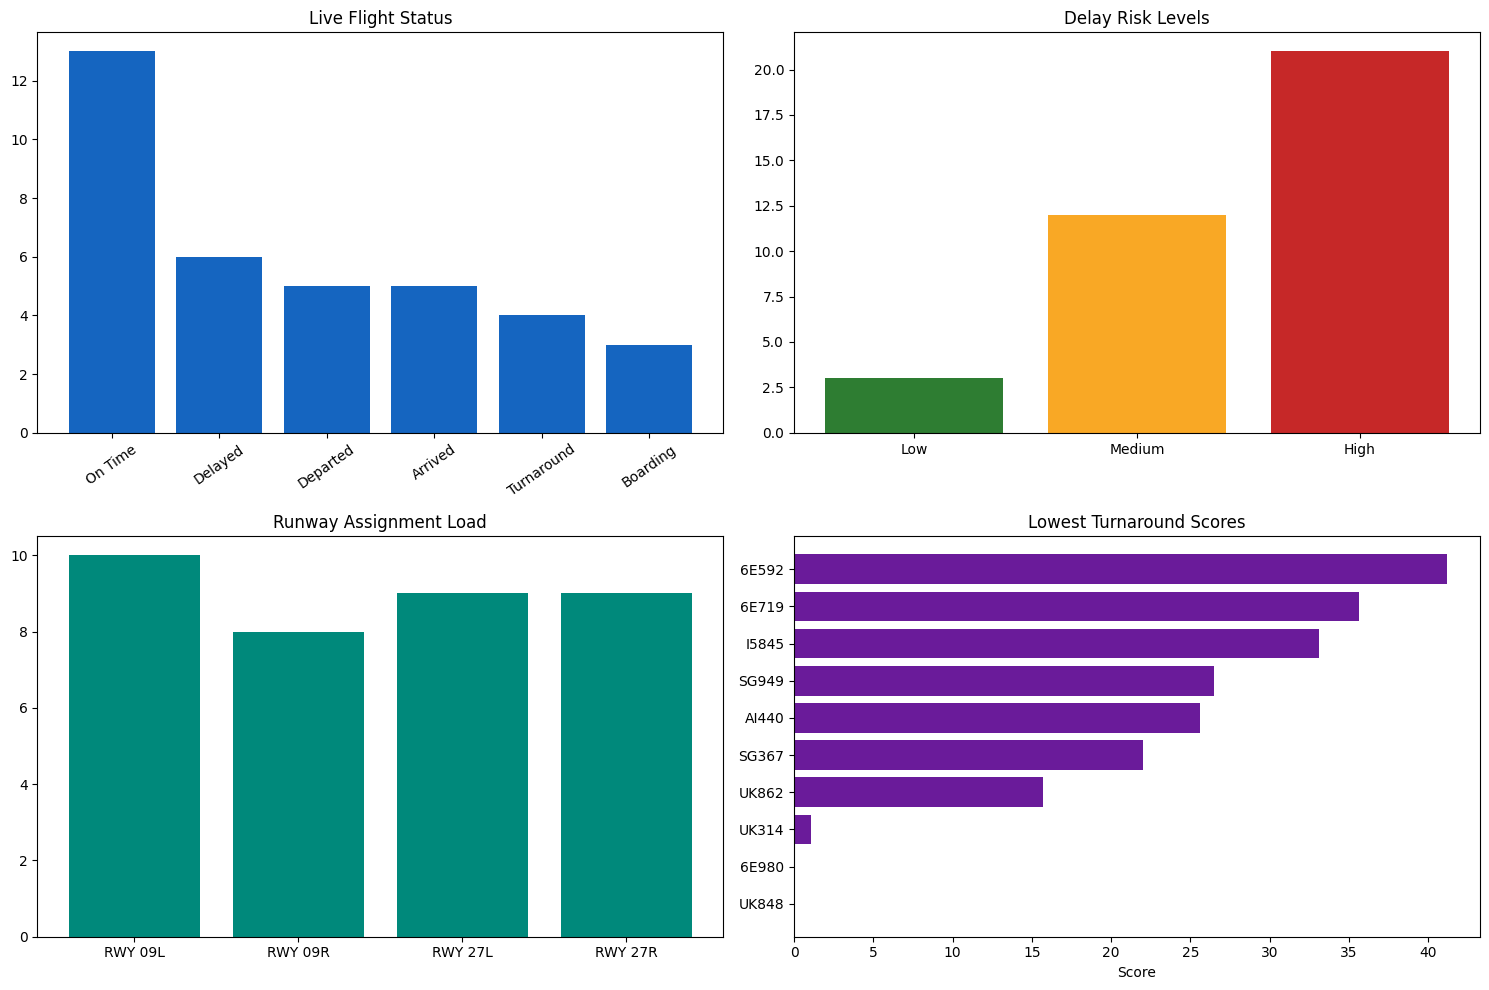

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

status_counts = ops_df['status'].value_counts()
axes[0, 0].bar(status_counts.index, status_counts.values, color='#1565c0')
axes[0, 0].set_title('Live Flight Status')
axes[0, 0].tick_params(axis='x', rotation=35)

risk_counts = ops_df['delay_risk_level'].value_counts().reindex(['Low', 'Medium', 'High'], fill_value=0)
axes[0, 1].bar(risk_counts.index.astype(str), risk_counts.values, color=['#2e7d32', '#f9a825', '#c62828'])
axes[0, 1].set_title('Delay Risk Levels')

runway_counts = ops_df['runway'].value_counts().reindex(RUNWAYS, fill_value=0)
axes[1, 0].bar(runway_counts.index, runway_counts.values, color='#00897b')
axes[1, 0].set_title('Runway Assignment Load')

top_turnaround = ops_df.sort_values('turnaround_score').head(10)
axes[1, 1].barh(top_turnaround['flight_id'], top_turnaround['turnaround_score'], color='#6a1b9a')
axes[1, 1].set_title('Lowest Turnaround Scores')
axes[1, 1].set_xlabel('Score')

plt.tight_layout()
plt.show()

## 10. Backend-Ready Payload

In [10]:
def build_flight_operation_payload(ops, kpis, conflicts, actions):
    board_columns = [
        'id', 'flight_id', 'airline', 'aircraft_type', 'origin', 'destination', 'status', 'is_arrival',
        'scheduled_arrival_time', 'actual_arrival_time', 'scheduled_departure_time', 'actual_departure_time',
        'assigned_gate', 'parking_bay', 'runway', 'baggage_belt', 'gpu_unit', 'turnaround_score',
        'delay_risk_score', 'delay_risk_level'
    ]
    return {
        'generated_at': now.isoformat(),
        'kpis': kpis.iloc[0].to_dict(),
        'live_flight_board': ops[board_columns].assign(delay_risk_level=lambda df: df['delay_risk_level'].astype(str)).to_dict(orient='records'),
        'top_risks': ops.sort_values('delay_risk_score', ascending=False).head(10)[board_columns].assign(delay_risk_level=lambda df: df['delay_risk_level'].astype(str)).to_dict(orient='records'),
        'conflicts': conflicts.to_dict(orient='records') if not conflicts.empty else [],
        'actions': actions.head(15).to_dict(orient='records'),
    }


payload = build_flight_operation_payload(ops_df, kpi_df, conflicts_df, actions_df)
payload

{'generated_at': '2026-04-27T09:00:00',
 'kpis': {'total_flights': 36.0,
  'arrivals': 18.0,
  'departures': 18.0,
  'on_time_departure_pct': 47.2,
  'avg_arrival_delay_min': 5.4,
  'avg_departure_delay_min': 10.5,
  'avg_turnaround_score': 48.9,
  'gate_assignment_pct': 80.6,
  'gpu_assignment_pct': 100.0,
  'open_conflicts': 7.0,
  'high_risk_flights': 21.0,
  'critical_actions': 19.0,
  'flight_operation_score': 53.4},
 'live_flight_board': [{'id': 'FL-1020',
   'flight_id': 'UK848',
   'airline': 'Vistara',
   'aircraft_type': 'ATR72',
   'origin': 'MAA',
   'destination': 'GOI',
   'status': 'Turnaround',
   'is_arrival': False,
   'scheduled_arrival_time': '07:01',
   'actual_arrival_time': '07:31',
   'scheduled_departure_time': '07:53',
   'actual_departure_time': '08:26',
   'assigned_gate': 'G01',
   'parking_bay': 'Bay A1',
   'runway': 'RWY 09L',
   'baggage_belt': 'B01',
   'gpu_unit': 'GPU-01',
   'turnaround_score': 0.0,
   'delay_risk_score': 100.0,
   'delay_risk_level

In [11]:
print('FLIGHT OPERATION SUMMARY')
print('========================')
print(f"Total flights: {payload['kpis']['total_flights']}")
print(f"On-time departure rate: {payload['kpis']['on_time_departure_pct']}%")
print(f"Average turnaround score: {payload['kpis']['avg_turnaround_score']}")
print(f"Gate assignment rate: {payload['kpis']['gate_assignment_pct']}%")
print(f"Open conflicts: {payload['kpis']['open_conflicts']}")
print(f"Flight Operation Score: {payload['kpis']['flight_operation_score']}")
print('\nTop AI actions:')
for action in payload['actions'][:5]:
    print(f"- {action['flight_id']}: {action['recommendation']}")

FLIGHT OPERATION SUMMARY
Total flights: 36.0
On-time departure rate: 47.2%
Average turnaround score: 48.9
Gate assignment rate: 80.6%
Open conflicts: 7.0
Flight Operation Score: 53.4

Top AI actions:
- UK848: Escalate to recovery desk; protect slot and pre-position baggage, cleaning, fueling, and pushback.
- UK314: Escalate to recovery desk; protect slot and pre-position baggage, cleaning, fueling, and pushback.
- SG367: Escalate to recovery desk; protect slot and pre-position baggage, cleaning, fueling, and pushback.
- 6E980: Escalate to recovery desk; protect slot and pre-position baggage, cleaning, fueling, and pushback.
- UK862: Escalate to recovery desk; protect slot and pre-position baggage, cleaning, fueling, and pushback.
